# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import pandas as pd

## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 0: Lectura de los datos agregados en Parquet

In [7]:
df_agg = spark.read.parquet("resultados/")

print(f"Se han cargado  {df_agg.count()} registros")
df_agg.show(5, truncate=False)

Se han cargado  248 registros
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|window                                    |sensor_id|avg_value         |avg_temp          |avg_humidity     |num_events|
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|{2026-02-06 22:21:30, 2026-02-06 22:22:00}|S4       |28.16125          |60.44125          |45.34375         |8         |
|{2026-02-06 22:21:30, 2026-02-06 22:22:00}|S2       |31.235            |62.5625           |58.28            |8         |
|{2026-02-06 22:10:30, 2026-02-06 22:11:00}|S4       |27.46             |31.895000000000003|57.4725          |4         |
|{2026-02-06 22:10:30, 2026-02-06 22:11:00}|S3       |36.82             |61.67             |46.93            |1         |
|{2026-02-06 22:11:00, 2026-02-06 22:11:30}|S3       |30.732999999999997|58.723            |54.31699999999999|10    

### Ejercicio 1

In [8]:
df_agg.printSchema()

total_filas = df_agg.count()
print(f"El dataframe tiene {total_filas} filas")

sensores_unicos = df_agg.select("sensor_id").distinct().count()
print(f"Hay {sensores_unicos} sensores diferentes")

df_agg.select("sensor_id").distinct().orderBy("sensor_id").show()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

El dataframe tiene 248 filas
Hay 4 sensores diferentes
+---------+
|sensor_id|
+---------+
|       S1|
|       S2|
|       S3|
|       S4|
+---------+



### Ejercicio 2

In [9]:
df_ratio = df_agg.withColumn("ratio_temp_hum", F.round(col("avg_temp") / col("avg_humidity"), 3))

resultado = df_ratio.select(
    F.min("ratio_temp_hum").alias("minimo"),
    F.max("ratio_temp_hum").alias("maximo"),
    F.round(F.avg("ratio_temp_hum"), 3).alias("media")
).collect()[0]

print(f"Minimo: {resultado['minimo']}")
print(f"Maximo: {resultado['maximo']}")
print(f"Media: {resultado['media']}")

df_ratio.select("sensor_id", "avg_temp", "avg_humidity", "ratio_temp_hum").show()

Minimo: 0.412
Maximo: 1.768
Media: 1.022
+---------+------------------+------------------+--------------+
|sensor_id|          avg_temp|      avg_humidity|ratio_temp_hum|
+---------+------------------+------------------+--------------+
|       S4|          60.44125|          45.34375|         1.333|
|       S2|           62.5625|             58.28|         1.073|
|       S4|31.895000000000003|           57.4725|         0.555|
|       S3|             61.67|             46.93|         1.314|
|       S3|            58.723| 54.31699999999999|         1.081|
|       S1|          63.45875|50.058749999999996|         1.268|
|       S4| 50.80571428571428| 43.82285714285714|         1.159|
|       S1| 43.96000000000001| 49.31099999999999|         0.891|
|       S3|47.048333333333325| 43.98666666666667|          1.07|
|       S4| 68.52000000000001|            48.372|         1.417|
|       S1|            54.574|            51.822|         1.053|
|       S3| 65.30666666666666| 53.10916666666666|

### Ejercicio 3

In [10]:
df_filtrado = df_agg.filter(
    (col("avg_humidity") > 45) &
    (col("num_events") >= 5) &
    (col("sensor_id").isin("S2", "S4"))
)

registros_filtrados = df_filtrado.count()
print(f"Hay {registros_filtrados} registros que pasan el filtro")
print(f"Eso es un {(registros_filtrados / df_agg.count()) * 100:.1f}% del total")

df_filtrado.show(truncate=False)

Hay 102 registros que pasan el filtro
Eso es un 41.1% del total
+------------------------------------------+---------+------------------+------------------+------------------+----------+
|window                                    |sensor_id|avg_value         |avg_temp          |avg_humidity      |num_events|
+------------------------------------------+---------+------------------+------------------+------------------+----------+
|{2026-02-06 22:21:30, 2026-02-06 22:22:00}|S4       |28.16125          |60.44125          |45.34375          |8         |
|{2026-02-06 22:21:30, 2026-02-06 22:22:00}|S2       |31.235            |62.5625           |58.28             |8         |
|{2026-02-06 22:12:00, 2026-02-06 22:12:30}|S4       |30.02             |68.52000000000001 |48.372            |5         |
|{2026-02-06 22:12:30, 2026-02-06 22:13:00}|S4       |36.457142857142856|55.83142857142857 |53.68142857142857 |7         |
|{2026-02-06 22:13:00, 2026-02-06 22:13:30}|S4       |23.902            |60

### Ejercicio 4

In [11]:
resumen_sensor = df_agg.groupBy("sensor_id").agg(
    F.round(F.avg("avg_value"), 2).alias("media_valor"),
    F.round(F.max("avg_value"), 2).alias("max_valor"),
    F.round(F.min("avg_value"), 2).alias("min_valor"),
    F.round(F.max("avg_temp"), 2).alias("temp_maxima"),
    F.round(F.avg("avg_temp"), 2).alias("media_temp"),
    F.round(F.avg("avg_humidity"), 2).alias("media_humedad"),
    F.sum("num_events").alias("eventos_totales"),
    F.count("*").alias("num_ventanas")
).orderBy("sensor_id")

resumen_sensor.show(truncate=False)

top_sensor = resumen_sensor.orderBy(col("media_valor").desc()).first()
print(f"El sensor con mayor media es {top_sensor['sensor_id']} con {top_sensor['media_valor']}")

top_temp = resumen_sensor.orderBy(col("temp_maxima").desc()).first()
print(f"La temp mas alta la tiene {top_temp['sensor_id']} con {top_temp['temp_maxima']}")

print("\nVentanas por sensor:")
resumen_sensor.select("sensor_id", "num_ventanas").show()

+---------+-----------+---------+---------+-----------+----------+-------------+---------------+------------+
|sensor_id|media_valor|max_valor|min_valor|temp_maxima|media_temp|media_humedad|eventos_totales|num_ventanas|
+---------+-----------+---------+---------+-----------+----------+-------------+---------------+------------+
|S1       |30.07      |42.8     |18.06    |71.07      |55.23     |54.76        |448            |62          |
|S2       |30.42      |39.88    |19.0     |69.95      |54.9      |56.4         |449            |62          |
|S3       |30.49      |40.36    |19.5     |71.19      |54.55     |54.93        |477            |62          |
|S4       |29.66      |40.96    |13.1     |75.11      |55.62     |53.97        |464            |62          |
+---------+-----------+---------+---------+-----------+----------+-------------+---------------+------------+

El sensor con mayor media es S3 con 30.49
La temp mas alta la tiene S4 con 75.11

Ventanas por sensor:
+---------+-----

### Ejercicio 5

In [12]:
ventana_spec = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

df_ranking = df_agg.withColumn("row_num", F.row_number().over(ventana_spec))

df_top = df_ranking.filter(col("row_num") == 1)

print("Mayor avg_value por cada sensor:")
df_top.select("sensor_id", "window", "avg_value", "avg_temp", "avg_humidity", "num_events") \
      .orderBy("sensor_id").show(truncate=False)

maximo_global = df_top.orderBy(col("avg_value").desc()).first()
print(f"El maximo global lo tiene {maximo_global['sensor_id']} con {maximo_global['avg_value']:.2f}")

Mayor avg_value por cada sensor:
+---------+------------------------------------------+-----------------+------------------+-----------------+----------+
|sensor_id|window                                    |avg_value        |avg_temp          |avg_humidity     |num_events|
+---------+------------------------------------------+-----------------+------------------+-----------------+----------+
|S1       |{2026-02-06 22:33:30, 2026-02-06 22:34:00}|42.796           |48.704            |53.98            |5         |
|S2       |{2026-02-06 22:17:30, 2026-02-06 22:18:00}|39.878           |57.932            |54.29600000000001|5         |
|S3       |{2026-02-06 22:19:30, 2026-02-06 22:20:00}|40.36            |61.39666666666667 |55.90333333333333|6         |
|S4       |{2026-02-06 22:39:30, 2026-02-06 22:40:00}|40.96333333333334|44.550000000000004|57.27333333333332|6         |
+---------+------------------------------------------+-----------------+------------------+-----------------+----------+

### Ejercicio 6

In [13]:
info_sensores = spark.createDataFrame([
    ("S1", "Exterior", "Industrial"),
    ("S2", "Interior", "Residencial"),
    ("S3", "Exterior", "Comercial"),
    ("S4", "Interior", "Industrial")
], ["sensor_id", "ubicacion", "tipo"])

info_sensores.show()

df_completo = df_agg.join(info_sensores, "sensor_id", "inner")

print("Primeros 5 registros tras el join:")
df_completo.select(
    "sensor_id", "ubicacion", "tipo", "avg_value", "avg_temp", "avg_humidity", "num_events"
).show(5, truncate=False)

+---------+---------+-----------+
|sensor_id|ubicacion|       tipo|
+---------+---------+-----------+
|       S1| Exterior| Industrial|
|       S2| Interior|Residencial|
|       S3| Exterior|  Comercial|
|       S4| Interior| Industrial|
+---------+---------+-----------+

Primeros 5 registros tras el join:
+---------+---------+----------+------------------+-----------------+-----------------+----------+
|sensor_id|ubicacion|tipo      |avg_value         |avg_temp         |avg_humidity     |num_events|
+---------+---------+----------+------------------+-----------------+-----------------+----------+
|S1       |Exterior |Industrial|33.93454545454545 |59.49727272727273|56.91636363636364|11        |
|S1       |Exterior |Industrial|28.490000000000002|64.955           |64.575           |2         |
|S1       |Exterior |Industrial|30.643            |57.935           |55.682           |10        |
|S1       |Exterior |Industrial|28.7825           |60.32625         |66.1075          |8         |

### Ejercicio 7

In [14]:
df_tiempo = df_agg.withColumn("inicio_ventana", col("window.start"))
df_tiempo = df_tiempo.withColumn("minuto", F.date_trunc("minute", col("inicio_ventana")))

por_minuto = df_tiempo.groupBy("minuto").agg(
    F.count("*").alias("ventanas"),
    F.round(F.avg("avg_humidity"), 2).alias("humedad_media"),
    F.round(F.avg("avg_temp"), 2).alias("temp_media")
).orderBy("minuto")

por_minuto.show(truncate=False)

print(f"En total hay {por_minuto.count()} minutos distintos")

+-------------------+--------+-------------+----------+
|minuto             |ventanas|humedad_media|temp_media|
+-------------------+--------+-------------+----------+
|2026-02-06 22:10:00|4       |56.4         |54.55     |
|2026-02-06 22:11:00|8       |48.66        |56.47     |
|2026-02-06 22:12:00|8       |52.61        |53.39     |
|2026-02-06 22:13:00|8       |56.81        |52.25     |
|2026-02-06 22:14:00|8       |52.43        |58.09     |
|2026-02-06 22:15:00|8       |54.24        |57.13     |
|2026-02-06 22:16:00|8       |58.35        |53.8      |
|2026-02-06 22:17:00|8       |52.89        |60.26     |
|2026-02-06 22:18:00|8       |58.34        |54.28     |
|2026-02-06 22:19:00|8       |58.88        |58.09     |
|2026-02-06 22:20:00|8       |53.85        |53.87     |
|2026-02-06 22:21:00|8       |56.24        |54.17     |
|2026-02-06 22:22:00|8       |51.38        |54.34     |
|2026-02-06 22:23:00|8       |53.18        |56.07     |
|2026-02-06 22:24:00|8       |57.51        |58.0

### Ejercicio 8

In [15]:
df_repart = df_agg.repartition(4, "sensor_id")
df_repart = df_repart.withColumn("partition_id", F.spark_partition_id())

print(f"Particiones: {df_repart.rdd.getNumPartitions()}")

df_repart.groupBy("partition_id").agg(
    F.count("*").alias("registros"),
    F.collect_set("sensor_id").alias("sensores")
).orderBy("partition_id").show(truncate=False)

df_repart.select("partition_id", "sensor_id", "avg_value", "num_events").show()

Particiones: 4
+------------+---------+--------+
|partition_id|registros|sensores|
+------------+---------+--------+
|0           |62       |[S3]    |
|1           |124      |[S2, S4]|
|3           |62       |[S1]    |
+------------+---------+--------+

+------------+---------+------------------+----------+
|partition_id|sensor_id|         avg_value|num_events|
+------------+---------+------------------+----------+
|           0|       S3|             36.82|         1|
|           0|       S3|30.732999999999997|        10|
|           0|       S3|             36.23|         6|
|           0|       S3| 29.30333333333333|        12|
|           0|       S3|30.725714285714282|         7|
|           0|       S3|26.548000000000002|         5|
|           0|       S3|29.279999999999998|         8|
|           0|       S3| 32.28333333333333|         9|
|           0|       S3|            29.412|         5|
|           0|       S3|          26.64125|         8|
|           0|       S3|       

### Ejercicio 9

In [16]:
stats = df_agg.select(
    F.avg("avg_value").alias("media"),
    F.stddev("avg_value").alias("desviacion")
).collect()[0]

media_val = stats["media"]
std_val = stats["desviacion"]

print(f"Media de avg_value: {media_val:.2f}")
print(f"Desviacion estandar: {std_val:.2f}")

df_anomalias = df_agg.withColumn(
    "es_anomalia",
    F.when(
        F.abs(col("avg_value") - media_val) > 1.5 * std_val,
        True
    ).otherwise(False)
)

num_anomalos = df_anomalias.filter(col("es_anomalia") == True).count()
print(f"\nSe detectan {num_anomalos} anomalias ({(num_anomalos / df_agg.count()) * 100:.1f}%)")

print("\nPor sensor:")
df_anomalias.filter(col("es_anomalia") == True).groupBy("sensor_id").agg(
    F.count("*").alias("anomalias")
).orderBy(col("anomalias").desc()).show()

df_anomalias.filter(col("es_anomalia") == True).select(
    "sensor_id", "avg_value", "avg_temp", "avg_humidity", "num_events"
).show(truncate=False)

Media de avg_value: 30.16
Desviacion estandar: 4.50

Se detectan 29 anomalias (11.7%)

Por sensor:
+---------+---------+
|sensor_id|anomalias|
+---------+---------+
|       S4|        9|
|       S1|        7|
|       S3|        7|
|       S2|        6|
+---------+---------+

+---------+------------------+------------------+------------------+----------+
|sensor_id|avg_value         |avg_temp          |avg_humidity      |num_events|
+---------+------------------+------------------+------------------+----------+
|S1       |36.912            |54.574            |51.822            |5         |
|S1       |41.80666666666667 |67.13666666666667 |75.69333333333334 |3         |
|S4       |13.1              |65.145            |54.6525           |4         |
|S3       |19.4975           |47.94             |49.006249999999994|8         |
|S3       |40.36             |61.39666666666667 |55.90333333333333 |6         |
|S1       |39.868            |35.519999999999996|53.35             |5         |
|S3 

### Ejercicio 10

In [17]:
df_puntuacion = df_agg.withColumn(
    "score",
    F.round((col("avg_value") * 0.5) + (col("avg_temp") * 0.3) + (col("avg_humidity") * 0.2), 2)
)

print("Top 10 por puntuacion:")
df_puntuacion.select("sensor_id", "score", "avg_value", "avg_temp", "avg_humidity") \
    .orderBy(col("score").desc()).show(10, truncate=False)

score_sensor = df_puntuacion.groupBy("sensor_id").agg(
    F.round(F.avg("score"), 2).alias("score_medio"),
    F.round(F.max("score"), 2).alias("score_max")
).orderBy(col("score_medio").desc())

score_sensor.show()

mejor = score_sensor.first()
print(f"Gana {mejor['sensor_id']} con score medio de {mejor['score_medio']} (max {mejor['score_max']})")

Top 10 por puntuacion:
+---------+-----+-----------------+-----------------+------------------+
|sensor_id|score|avg_value        |avg_temp         |avg_humidity      |
+---------+-----+-----------------+-----------------+------------------+
|S1       |56.18|41.80666666666667|67.13666666666667|75.69333333333334 |
|S4       |52.42|35.84125         |75.11250000000001|59.817499999999995|
|S2       |50.87|34.845           |68.395           |64.66             |
|S2       |50.15|35.782           |59.676           |71.79             |
|S3       |49.78|40.36            |61.39666666666667|55.90333333333333 |
|S4       |49.66|34.983           |69.397           |56.730000000000004|
|S3       |49.54|35.24857142857143|63.30428571428571|64.61285714285715 |
|S4       |49.47|33.688           |64.26599999999999|66.75             |
|S2       |49.17|35.85166666666667|60.135           |66.01333333333334 |
|S1       |49.16|33.258           |71.06800000000001|56.072            |
+---------+-----+-----------

### Ejercicio 11

In [18]:
df_pd = df_agg.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "num_events").toPandas()
df_pd.head()

,sensor_id,avg_value,avg_temp,avg_humidity,num_events
0,S4,28.16125,60.44125,45.34375,8
1,S2,31.23500,62.56250,58.28000,8
2,S4,27.46000,31.89500,57.47250,4
3,S3,36.82000,61.67000,46.93000,1
4,S3,30.73300,58.72300,54.31700,10


<Figure size 1000x500 with 0 Axes>

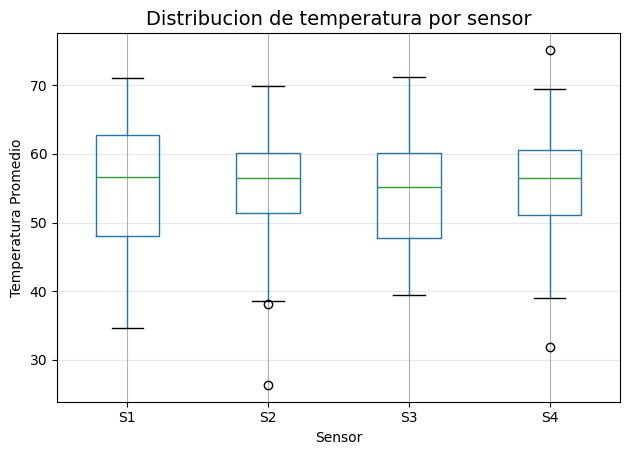

In [19]:
plt.figure(figsize=(10, 5))
df_pd.boxplot(column="avg_temp", by="sensor_id")
plt.title("Distribucion de temperatura por sensor", fontsize=14)
plt.suptitle("")
plt.xlabel("Sensor")
plt.ylabel("Temperatura Promedio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

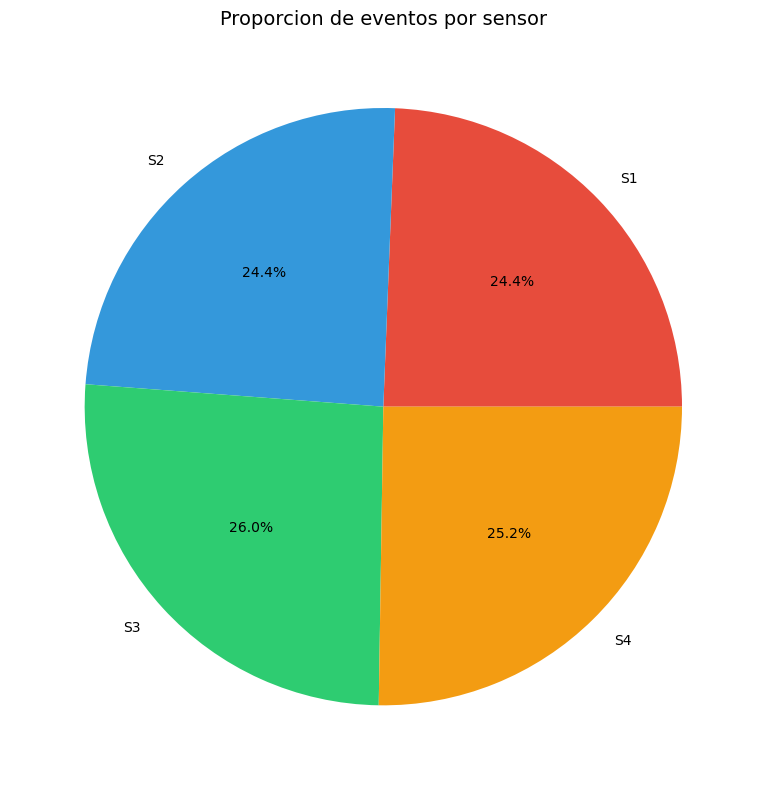

In [20]:
eventos_por_sensor = df_pd.groupby("sensor_id")["num_events"].sum()

plt.figure(figsize=(8, 8))
plt.pie(eventos_por_sensor, labels=eventos_por_sensor.index, autopct="%1.1f%%",
        colors=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"])
plt.title("Proporcion de eventos por sensor", fontsize=14)
plt.tight_layout()
plt.show()